# Santander Customer Satisfaction

## 1. Defining the Project

**Project Link:** https://www.kaggle.com/competitions/santander-customer-satisfaction/overview

### Challenge Description
The goal of this competition is to predict whether a customer is satisfied or dissatisfied with their banking experience at Santander Bank. Early identification of unhappy customers allows banks to take proactive steps to improve the customer relationship before it's too late. This is a binary classification problem where the target variable indicates customer satisfaction.

### Data Description
The dataset is provided by Santander Bank and contains hundreds of anonymized numerical features labeled `var1`, `var2`, etc. The training set consists of rows representing individual customers, each with a `TARGET` column where `0` indicates a satisfied customer and `1` indicates an unsatisfied customer. The feature names are anonymized, so we cannot rely on domain knowledge to interpret them directly.

## 2. Data Loading and Initial Look

In [67]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [68]:
print("Shape:", df.shape)
print("\nMissing Values:", df.isnull().sum().sum())

Shape: (76020, 371)

Missing Values: 0


In [69]:
numerical_features = df.drop(columns=['TARGET']).select_dtypes(include='number')
# drops the TARGET column so we're only looking at the input features
# select_dtypes keeps only numerical columns (removes any text/categorical ones)

print("Numerical features:", numerical_features.shape[1])  # how many numerical columns
print("\nRanges:")
numerical_features.describe().loc[['min', 'max']]  # we just grab min & max from describe()

Numerical features: 370

Ranges:


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38
min,1.0,-999999.0,5.0,0.0,0.00,0.00,0.00,0.00,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,5163.75
max,151838.0,238.0,105.0,210000.0,12888.03,21024.81,8237.82,11073.57,6600.0,6600.0,...,7331.34,50003.88,20385.72,138831.63,91778.73,438329.22,24650.01,681462.9,397884.3,22034738.76


TARGET
0    73012
1     3008
Name: count, dtype: int64

Imbalance ratio: 24.3:1


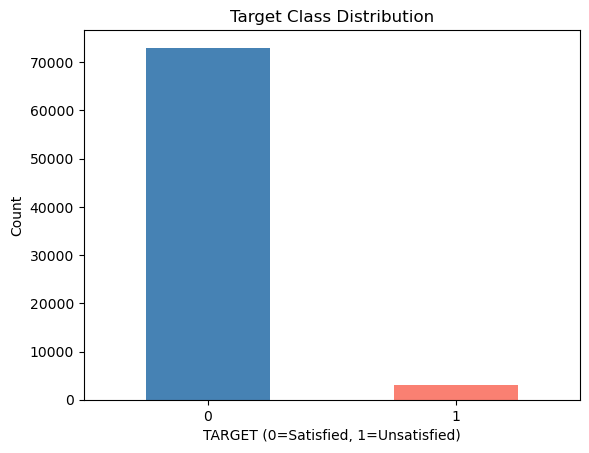

In [70]:
counts = df['TARGET'].value_counts()       # counts how many 0s and 1s are in TARGET
print(counts)
print(f"\nImbalance ratio: {round(counts[0]/counts[1], 1)}:1")  # ratio of satisfied
                                                                  # to unsatisfied customers
# the bar chart below visualizes that ratio so it's easy to see the imbalance
counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Target Class Distribution')
plt.xlabel('TARGET (0=Satisfied, 1=Unsatisfied)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [71]:
Q1 = numerical_features.quantile(0.25)   # 25th percentile of each feature
Q3 = numerical_features.quantile(0.75)   # 75th percentile of each feature
IQR = Q3 - Q1                            # interquartile range = spread of the middle 50%

# a value is an outlier if it's more than 1.5x the IQR below Q1 or above Q3
# this is the standard definition of an outlier
outliers = ((numerical_features < (Q1 - 1.5 * IQR)) | (numerical_features > (Q3 + 1.5 * IQR))).sum()
print("Features with outliers:", (outliers > 0).sum())  # how many features have at least one outlier

Features with outliers: 330


In [72]:
# Build feature summary table
summary = pd.DataFrame({
    'Type': numerical_features.dtypes,
    'Min': numerical_features.min(),
    'Max': numerical_features.max(),
    'Missing': numerical_features.isnull().sum(),
    'Has Outliers': ((numerical_features < (Q1 - 1.5 * IQR)) | 
                     (numerical_features > (Q3 + 1.5 * IQR))).any()
})

print(summary.head(20))  # just preview first 20 rows

                            Type       Min        Max  Missing  Has Outliers
ID                         int64       1.0  151838.00        0         False
var3                       int64 -999999.0     238.00        0          True
var15                      int64       5.0     105.00        0          True
imp_ent_var16_ult1       float64       0.0  210000.00        0          True
imp_op_var39_comer_ult1  float64       0.0   12888.03        0          True
imp_op_var39_comer_ult3  float64       0.0   21024.81        0          True
imp_op_var40_comer_ult1  float64       0.0    8237.82        0          True
imp_op_var40_comer_ult3  float64       0.0   11073.57        0          True
imp_op_var40_efect_ult1  float64       0.0    6600.00        0          True
imp_op_var40_efect_ult3  float64       0.0    6600.00        0          True
imp_op_var40_ult1        float64       0.0    8237.82        0          True
imp_op_var41_comer_ult1  float64       0.0   12888.03        0          True

In [73]:
# Grouped feature table
'''
Since we have 370 features we can't list them all individually, 
so we'll group them into a summary row in the table instead.
'''
group_summary = pd.DataFrame([
    {
        'Feature Group': 'ID',
        'Type': 'Numerical (int64)',
        'Range': '1 to 151,838',
        'Missing': 0,
        'Has Outliers': 'No'
    },
    {
        'Feature Group': 'var3 (suspicious)',
        'Type': 'Numerical (int64)',
        'Range': '-999,999 to 238',
        'Missing': 0,
        'Has Outliers': 'Yes'
    },
    {
        'Feature Group': 'var15 and other int features',
        'Type': 'Numerical (int64)',
        'Range': '5 to 105',
        'Missing': 0,
        'Has Outliers': 'Yes'
    },
    {
        'Feature Group': 'imp_* float features (367 features)',
        'Type': 'Numerical (float64)',
        'Range': '0.0 to ~131,100',
        'Missing': 0,
        'Has Outliers': 'Yes (330/370 features)'
    },
    {
        'Feature Group': 'TARGET',
        'Type': 'Numerical (int64)',
        'Range': '0 or 1',
        'Missing': 0,
        'Has Outliers': 'N/A'
    }
])

group_summary

,Feature Group,Type,Range,Missing,Has Outliers
0,ID,Numerical (int64),"1 to 151,838",0,No
1,var3 (suspicious),Numerical (int64),"-999,999 to 238",0,Yes
2,var15 and other int features,Numerical (int64),5 to 105,0,Yes
3,imp_* float features (367 features),Numerical (float64),"0.0 to ~131,100",0,Yes (330/370 features)
4,TARGET,Numerical (int64),0 or 1,0,N/A


## Results from Data Loading and Initial Look

### Dataset Overview
The training dataset contains **76,020 customers** and **371 columns** — 370 input features and 1 target column. All 370 features are numerical (a mix of `int64` and `float64`), and there are **no missing values** in the traditional sense. However, `var3` contains values of `-999999` which are almost certainly placeholders for missing data and will need to be handled in the cleaning step.

### Feature Summary
Since there are 370 features, we group them by type below rather than listing each individually.

### Missing Values
No null values were found across any column.

### Outliers
An outlier is defined as any value that falls more than **1.5 times the IQR** (interquartile range) below the 25th percentile or above the 75th percentile. By this definition, **330 out of 370 features** contain at least one outlier, which is common in real-world financial data.

### Class Imbalance
The target column is highly imbalanced:
- **Satisfied (0):** 73,012 customers
- **Unsatisfied (1):** 3,008 customers
- **Ratio:** 24.3:1

This means unsatisfied customers make up only about 4% of the dataset. We will address this during modeling using `class_weight='balanced'`.

### Target Encoding
This is a **binary classification** task. The target is encoded as:
- `0` = Satisfied customer
- `1` = Unsatisfied customer

## 3. Data Visualization

Since we have 370 features we can't plot all of them individually, so instead we:

* Plot histograms for a selection of the most promising features side by side comparing class 0 vs class 1
* Then comment on which features look most useful for the ML task

In [74]:
# split the dataset into satisfied and unsatisfied customers
class0 = df[df['TARGET'] == 0]
class1 = df[df['TARGET'] == 1]

# find features that differ the most between classes
# by comparing the absolute difference in means
mean_diff = abs(class0[numerical_features.columns].mean() - 
                class1[numerical_features.columns].mean())

# get top 7 most different features between classes
top_features = mean_diff.sort_values(ascending=False).head(7)
print(top_features)

delta_imp_aport_var13_1y3     2.990801e+07
delta_num_aport_var13_1y3     2.990801e+07
delta_num_venta_var44_1y3     5.752479e+06
delta_imp_venta_var44_1y3     5.752479e+06
delta_num_compra_var44_1y3    2.664601e+06
delta_imp_compra_var44_1y3    2.664601e+06
delta_num_aport_var17_1y3     1.880156e+06
dtype: float64


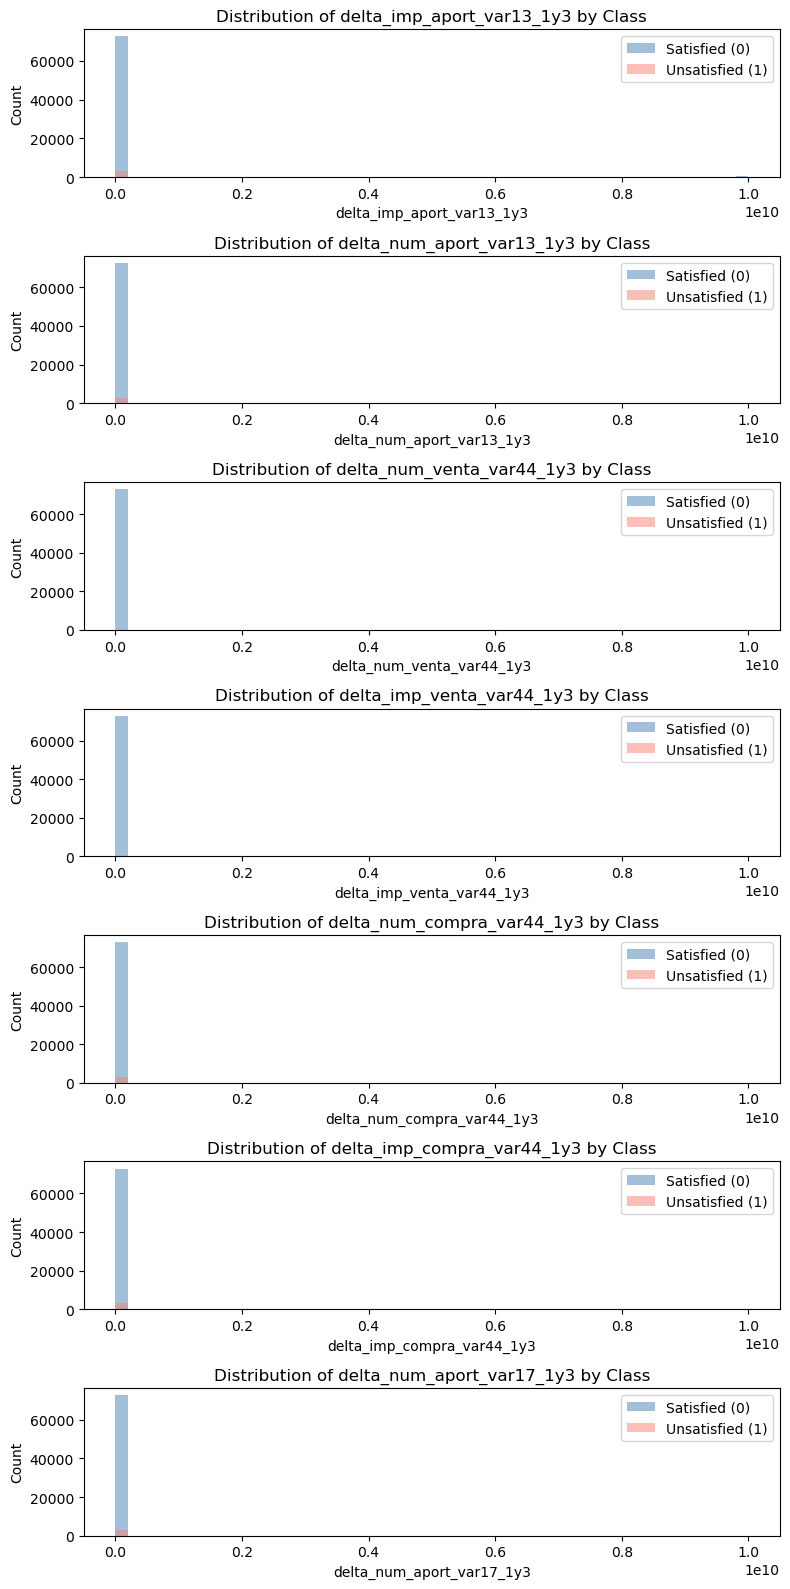

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(7, 1, figsize=(8, 16))

for ax, feature in zip(axes, top_features.index):
    ax.hist(class0[feature], bins=50, alpha=0.5, label='Satisfied (0)', color='steelblue')
    ax.hist(class1[feature], bins=50, alpha=0.5, label='Unsatisfied (1)', color='salmon')
    ax.set_title(f'Distribution of {feature} by Class')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

In [76]:
# check how many values are zero in the delta features
for feature in top_features.index:
    pct_zero = (df[feature] == 0).mean() * 100
    print(f"{feature}: {pct_zero:.1f}% zeros")

delta_imp_aport_var13_1y3: 97.3% zeros
delta_num_aport_var13_1y3: 97.3% zeros
delta_num_venta_var44_1y3: 99.9% zeros
delta_imp_venta_var44_1y3: 99.9% zeros
delta_num_compra_var44_1y3: 99.9% zeros
delta_imp_compra_var44_1y3: 99.9% zeros
delta_num_aport_var17_1y3: 99.9% zeros


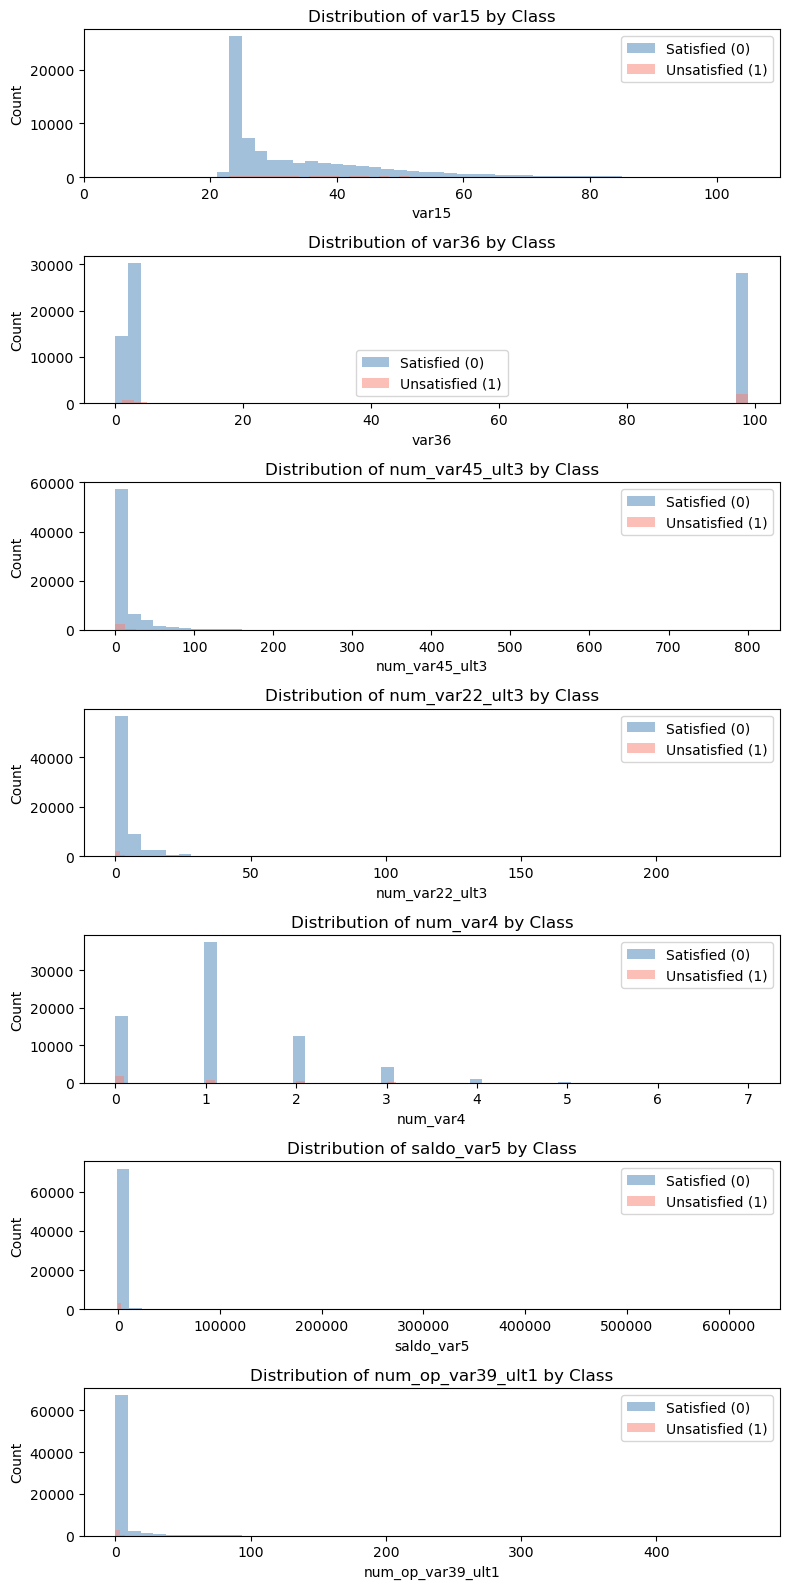

In [77]:
# the top features by mean difference are dominated by extreme outliers
# making the histograms unreadable, so we manually select more interpretable features

top_features_manual = ['var15', 'var36', 'num_var45_ult3', 'num_var22_ult3', 
                        'num_var4', 'saldo_var5', 'num_op_var39_ult1']

fig, axes = plt.subplots(7, 1, figsize=(8, 16))

for ax, feature in zip(axes, top_features_manual):
    ax.hist(class0[feature], bins=50, alpha=0.5, label='Satisfied (0)', color='steelblue')
    ax.hist(class1[feature], bins=50, alpha=0.5, label='Unsatisfied (1)', color='salmon')
    ax.set_title(f'Distribution of {feature} by Class')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

## Results from Data Visualization

We first attempted to select features using the largest mean difference between classes,
but those features (`delta_*`) turned out to be between 97-99.9% zeros, making the 
histograms unreadable as all the data was squished into a single bar at zero. We then manually selected a set of features that appeared more readable and interpretable 
for visualization purposes.

Here, the salmon bars (unsatisfied) are small throughout due to the 24.3:1 class imbalance.


- **var15**: Likely represents age. Satisfied customers peak sharply around 23-25, 
while unsatisfied customers appear more spread out toward older ages. This is the 
most promising feature visually.

- **var36**: Has two distinct clusters near 0 and near 100. Both classes follow a 
very similar pattern, suggesting this feature may not be very useful for 
distinguishing between classes.

- **num_var45_ult3**: Most customers are clustered near 0. Unsatisfied customers 
appear slightly more spread out but the difference is not very clear.

- **num_var22_ult3**: Similar to above — heavily concentrated near 0 with a long 
tail. No strong visual separation between classes.

- **num_var4**: Interesting discrete distribution with peaks at 0, 1, 2, and 3. 
Both classes follow a similar pattern here.

- **saldo_var5**: Almost all customers are at 0, with a long tail of outliers. 
Hard to draw conclusions.

- **num_op_var39_ult1**: Heavily concentrated near 0 for both classes. 
Not very informative visually.

**Overall:** `var15` is the most promising feature, showing the clearest visual 
difference between satisfied and unsatisfied customers. Most other features are 
heavily skewed toward zero making visual separation difficult.

## 4. Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [78]:
# drop the ID column as it is just a row identifier and not a useful feature
df = df.drop(columns=['ID'])

# drop columns that are more than 99% zeros as they carry almost no information
zero_percent = (df == 0).mean() * 100
cols_to_drop = zero_percent[zero_percent > 99].index
print(f"Columns dropped (>99% zeros): {len(cols_to_drop)}")
print(cols_to_drop.tolist())

df = df.drop(columns=cols_to_drop)
print(f"\nRemaining columns: {df.shape[1]}")

Columns dropped (>99% zeros): 220
['imp_op_var40_comer_ult1', 'imp_op_var40_comer_ult3', 'imp_op_var40_efect_ult1', 'imp_op_var40_efect_ult3', 'imp_op_var40_ult1', 'imp_sal_var16_ult1', 'ind_var1', 'ind_var2_0', 'ind_var2', 'ind_var6_0', 'ind_var6', 'ind_var13_largo', 'ind_var13_medio_0', 'ind_var13_medio', 'ind_var14', 'ind_var17_0', 'ind_var17', 'ind_var18_0', 'ind_var18', 'ind_var19', 'ind_var20_0', 'ind_var20', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var29_0', 'ind_var29', 'ind_var31_0', 'ind_var31', 'ind_var32_cte', 'ind_var32_0', 'ind_var32', 'ind_var33_0', 'ind_var33', 'ind_var34_0', 'ind_var34', 'ind_var40', 'ind_var41', 'ind_var39', 'ind_var44_0', 'ind_var44', 'ind_var46_0', 'ind_var46', 'num_var1', 'num_var6_0', 'num_var6', 'num_var13_largo', 'num_var13_medio_0', 'num_var13_medio', 'num_var14', 'num_var17_0', 'num_var17', 'num_var18_0', 'num_var18', 'num_var20_0', 'num_var20', 'num_op_var40_hace2', 'num_op_var40_hace3', 'num_op_var40_ult1', 'num_op_var40_

In [79]:
# replace -999999 in var3 with the median
# -999999 is clearly a placeholder for missing data, not a real value
median_var3 = df['var3'].median()
print(f"Median of var3: {median_var3}")

df['var3'] = df['var3'].replace(-999999, median_var3)
print(f"Min of var3 after cleaning: {df['var3'].min()}")

Median of var3: 2.0
Min of var3 after cleaning: 0


In [80]:
# check for suspicious minimum values across all features
suspicious = X[X < -999].any()
suspicious_cols = suspicious[suspicious].index
print(f"Columns with values below -999: {len(suspicious_cols)}")
print(suspicious_cols.tolist())

Columns with values below -999: 6
['saldo_var5', 'saldo_var8', 'saldo_var30', 'saldo_var42', 'saldo_medio_var8_ult1', 'saldo_medio_var8_ult3']


In [81]:
# check the minimum values of these suspicious columns
for col in suspicious_cols:
    print(f"{col}: min = {X[col].min()}")

saldo_var5: min = -2895.72
saldo_var8: min = -4942.26
saldo_var30: min = -4942.26
saldo_var42: min = -4942.26
saldo_medio_var8_ult1: min = -3401.34
saldo_medio_var8_ult3: min = -1844.52


In [82]:
from sklearn.preprocessing import StandardScaler

# separate features and target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# apply standard scaler - important for logistic regression
# it scales every feature to have mean=0 and standard deviation=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# convert back to dataframe for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling complete!")
print(f"Features shape: {X_scaled.shape}")

Scaling complete!
Features shape: (76020, 149)


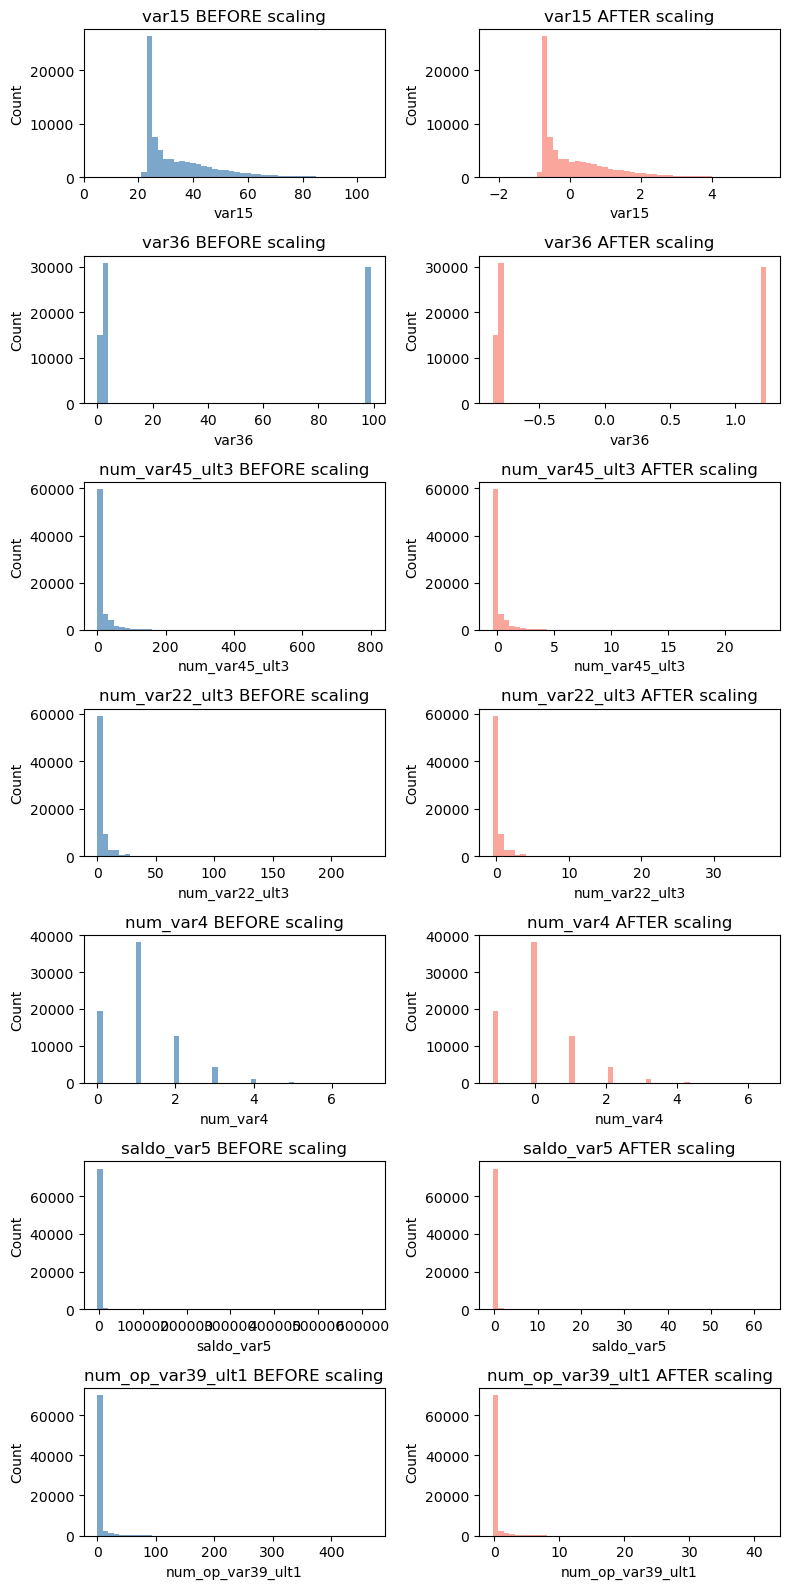

In [83]:
#visualization after cleaning
features_to_plot = ['var15', 'var36', 'num_var45_ult3', 'num_var22_ult3', 
                    'num_var4', 'saldo_var5', 'num_op_var39_ult1']

fig, axes = plt.subplots(7, 2, figsize=(8,16))

for i, feature in enumerate(features_to_plot):
    # before scaling
    axes[i, 0].hist(X[feature], bins=50, color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{feature} BEFORE scaling')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Count')

    # after scaling
    axes[i, 1].hist(X_scaled[feature], bins=50, color='salmon', alpha=0.7)
    axes[i, 1].set_title(f'{feature} AFTER scaling')
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [84]:
# check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# check for constant columns (only one unique value)
constant_cols = [col for col in X.columns if X[col].nunique() == 1]
print(f"Constant columns: {len(constant_cols)}")

Duplicate rows: 4841
Constant columns: 0


In [85]:
# check for duplicate columns
duplicate_cols = X.T.duplicated()
print(f"Duplicate columns: {duplicate_cols.sum()}")

Duplicate columns: 6


In [86]:
# drop duplicate rows
df = df.drop_duplicates()
print(f"Rows after dropping duplicates: {df.shape[0]}")

# re-separate features and target after dropping duplicates
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# drop duplicate columns
X = X.T.drop_duplicates().T
print(f"Columns after dropping duplicate columns: {X.shape[1]}")

Rows after dropping duplicates: 71179
Columns after dropping duplicate columns: 143


In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling complete!")
print(f"Features shape: {X_scaled.shape}")

Scaling complete!
Features shape: (71179, 143)


## Results from Data Cleaning and Preparation for Machine Learning

### Cleaning Steps

**1. Dropped the ID column**
The `ID` column is just a row identifier and carries no predictive information 
for the model.

**2. Dropped columns with more than 99% zeros**
220 out of 370 features were more than 99% zeros, meaning they carry almost no 
useful information. These were dropped, reducing our feature set from 370 to 149.

**3. Fixed var3**
`var3` contained values of `-999999` which we noticed during the Data Loading 
section. These are clearly placeholders for missing data, not real values. 
They were replaced with the median value of `var3` which is `2.0`.

**4. Checked for other suspicious values**
We checked all features for other extreme negative values. Six `saldo_*` features 
had negative minimums, but these represent realistic negative bank balances 
(overdrafts) and were left as is.

**5. Dropped duplicate rows**
4,841 duplicate rows (~6.4% of the data) were found and removed, 
leaving 71,179 rows.

**6. Dropped duplicate columns**
6 duplicate columns were found and removed, leaving a final feature set of 
143 features.

### Rescaling
Rescaling is important for Logistic Regression because the model is sensitive 
to the scale of features — a feature with values in the hundreds will dominate 
over a feature with values between 0 and 1. We applied **StandardScaler** to all 143 numerical features. The shape of 
the distributions remains the same after scaling, only the x-axis range changes 
as shown in the plots above.

## 5. Machine Learning

### Problem Formulation
All unnecessary columns were removed during the Data Cleaning section:
- `ID` column was dropped as it is just a row identifier
- 220 columns with more than 99% zeros were dropped
- 6 duplicate columns were dropped
- No categorical features were present so no one-hot encoding was needed
- The target is already properly encoded as 0 (satisfied) and 1 (unsatisfied)

Our final feature set contains 143 features and 71,179 rows.

In [88]:
from sklearn.model_selection import train_test_split

# split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (56943, 143)
Testing set size: (14236, 143)


In [89]:
from sklearn.linear_model import LogisticRegression

# train logistic regression model
# class_weight='balanced' handles the class imbalance (24.3:1 ratio)
# max_iter=1000 gives the model enough iterations to converge
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [90]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# make predictions on test set
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

# compute metrics
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC Score: {auc_roc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6926
AUC-ROC Score: 0.7900

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     13654
           1       0.09      0.72      0.16       582

    accuracy                           0.69     14236
   macro avg       0.54      0.70      0.49     14236
weighted avg       0.95      0.69      0.79     14236



In [91]:
# load test data
test_df = pd.read_csv('test.csv')

# save the ID column for submission file
test_ids = test_df['ID']

# apply same cleaning steps as train data
test_df = test_df.drop(columns=['ID'])

# replace -999999 in var3 with the same median we used for training
test_df['var3'] = test_df['var3'].replace(-999999, median_var3)

# keep only the same columns as our trained model
test_df = test_df[X.columns]

# convert to dataframe and apply the same scaler fit on training data
test_scaled = pd.DataFrame(scaler.transform(test_df), columns=X.columns)

# generate predictions
test_predictions = lr.predict_proba(test_scaled)[:, 1]

# create submission file
submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file created!")
print(submission.head())

Submission file created!
   ID    TARGET
0   2  0.324188
1   5  0.402321
2   6  0.216756
3   7  0.531229
4   9  0.201782


## Results from Machine Learning


### Train/Test Split
The data was split into 80% training (56,943 rows) and 20% test (14,236 rows).

### Training
We trained a Logistic Regression model with `class_weight='balanced'` to handle 
the 24.3:1 class imbalance, and `max_iter=1000` to ensure the model converges.

### Evaluation on Test Set
- **Accuracy: 69.26%** : this is a result of 
`class_weight='balanced'` forcing the model to pay attention to unsatisfied customers
- **AUC-ROC: 0.79** : this is the official Kaggle metric. A score of 0.5 means 
random guessing and 1.0 is perfect. 0.79 is a non-trivial result.
- **Recall for class 1: 72%** : the model correctly identifies 72% of unsatisfied 
customers which is the most important metric for our task.

### Applying to Kaggle Test Set
We applied the same cleaning and scaling steps to `test.csv` and generated a 
`submission.csv` file with predicted probabilities for each customer.